<a href="https://colab.research.google.com/github/aabaniel/ZeekData24-AI-Training/blob/main/CTTHES3_Models/ML_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Training Section

Support Vector Machine, Gradient Boosted Trees, and Random Forest

 1. **Split** the dataset for testing and validation into folds.
 1. **Select** a machine learning algorithm to be tested with the dataset by importing a specific machine learning algorithm in scikit-learn library.
 1. **Train** using the training folds and will be tested and evaluated using the validation folds wherein the researchers will also observe its accuracy, detection rate, recall, precision, false positive rate and take the average of it.
 1. **Evaluate** the combinations of the hyperparameters to maximize the performance of the model.          
 *If the best combination is found, then it will proceed to the next step. If not, then it will undergo hyperparameter tuning to find the best combination of the hyperparameters and will undergo training with the tuned hyperparameters.*
 1. The model will then be compared with the performance of other models to determine the best based on the given evaluation metrics.
 1. The best performing model will be then tested using the testing set that is still unseen by the model.

**Input** -===- Preprocessed Dataset

**Output** -==- Model & Scaler Output

In [44]:
# @title
!nvidia-smi

Mon Jun  1 09:52:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             31W /   70W |     437MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [45]:
# @title
%load_ext cuml.accel


The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [46]:
# @title
%pip install pandas numpy matplotlib scikit-learn imbalanced-learn

In [47]:
# @title
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, confusion_matrix

from sklearn.preprocessing import StandardScaler



In [48]:
# @title
from sklearn.metrics import make_scorer, confusion_matrix

def multiclass_weighted_fpr(y_true, y_pred):
    """Calculates the weighted False Positive Rate for multiclass classification."""
    cm = confusion_matrix(y_true, y_pred)

    # FP: Column sum - TP (diagonal)
    fp = cm.sum(axis=0) - np.diag(cm)
    # FN: Row sum - TP (diagonal)
    fn = cm.sum(axis=1) - np.diag(cm)
    # TP: Diagonal
    tp = np.diag(cm)
    # TN: Total - (FP + FN + TP)
    tn = cm.sum() - (fp + fn + tp)

    # FPR = FP / (FP + TN)
    fpr = fp / (fp + tn)

    # Handle potential division by zero
    fpr = np.nan_to_num(fpr)

    # Return weighted average based on class support (row sums)
    weights = cm.sum(axis=1)
    return np.average(fpr, weights=weights)

# Create the scorer object
fpr_scorer = make_scorer(multiclass_weighted_fpr)

In [57]:
##### FOR COLAB #####

train = "/content/final_train.csv"
test = "/content/test.csv"
'''
train = "/content/train_binary.csv"
test = "/content/test_binary.csv"

train = "../datasets/final_train.csv"
test = "../datasets/test.csv"
'''

df = pd.read_csv(train)
test_df = pd.read_csv(test)

df.head()



,label_binary_class,duration_bin_1.0,duration_bin_2.0,duration_bin_3.0,duration_bin_5.0,duration_bin_6.0,missed_bytes_bin_1.0,missed_bytes_bin_2.0,orig_bytes_bin_1.0,orig_bytes_bin_2.0,...,history_ShR,history_Sr,history_^dD,service_dce_rpc,service_ntlm,service_smb,service_dns,service_http,service_ssl,service_unknown
0,0,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
1,1,1,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,1,1,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,0,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0


In [50]:
X_train = df.drop(columns=["label_tactic"])
y_train = df["label_tactic"]

X_test = test_df.drop(columns=["label_tactic"])
y_test = test_df["label_tactic"]


In [58]:
'''
X_train = df.drop(columns=["label_binary_class"])
y_train = df["label_binary_class"]

X_test = test_df.drop(columns=["label_binary_class"])
y_test = test_df["label_binary_class"]
'''

In [59]:
# @title
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=10,
    class_weight='balanced',
    random_state=42,
    max_iter=20000,
    tol=1e-3,
    dual=False
)

scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted',
    'fpr_weighted': fpr_scorer
}

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    svm,
    X_train_scaled,
    y_train,
    cv=skf_10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "train_accuracy": cv_results["train_accuracy"],
    "test_accuracy": cv_results["test_accuracy"],
    "train_precision_weighted": cv_results["train_precision_weighted"],
    "test_precision_weighted": cv_results["test_precision_weighted"],
    "train_recall_weighted": cv_results["train_recall_weighted"],
    "test_recall_weighted": cv_results["test_recall_weighted"],
    "train_f1_weighted": cv_results["train_f1_weighted"],
    "test_f1_weighted": cv_results["test_f1_weighted"],
    "fit_time_sec": cv_results["fit_time"],
    "score_time_sec": cv_results["score_time"],
    "train_fpr": cv_results["train_fpr_weighted"],
    "test_fpr": cv_results["test_fpr_weighted"],
})

print("10-Fold Cross-Validation (Fold-by-Fold):")
print(cv_df.round(4).to_string(index=False))

print("\nSummary (test metrics):")
for metric in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted"]:
    vals = cv_results[metric]
    print(f"{metric}: mean={vals.mean():.4f}, std={vals.std():.4f}, min={vals.min():.4f}, max={vals.max():.4f}")

print("\nGeneralization gap (train - test, mean):")
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    gap = cv_results[f"train_{metric}"].mean() - cv_results[f"test_{metric}"].mean()
    print(f"{metric}: {gap:.4f}")

param_grid = [
    {
        'loss': ['hinge'],
        'dual': [True],
        'C': [0.01, 0.1, 1, 10, 100],
        'tol': [1e-4, 1e-3, 1e-2],
        'max_iter': [1000, 5000, 10000],
    },
    {
        'loss': ['squared_hinge'],
        'dual': [True, False],
        'C': [0.01, 0.1, 1, 10, 100],
        'tol': [1e-4, 1e-3, 1e-2],
        'max_iter': [1000, 5000, 10000],
    }
]

grid_search = GridSearchCV(
    LinearSVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


10-Fold Cross-Validation (Fold-by-Fold):
 fold  train_accuracy  test_accuracy  train_precision_weighted  test_precision_weighted  train_recall_weighted  test_recall_weighted  train_f1_weighted  test_f1_weighted  fit_time_sec  score_time_sec  train_fpr  test_fpr
    1          0.9816         0.9802                    0.9822                   0.9809                 0.9816                0.9802             0.9815            0.9802        0.2232          0.6717     0.0189    0.0202
    2          0.9815         0.9803                    0.9822                   0.9811                 0.9815                0.9803             0.9815            0.9803        0.1548          0.5294     0.0189    0.0201
    3          0.9812         0.9831                    0.9819                   0.9836                 0.9812                0.9831             0.9812            0.9830        0.1703          0.0411     0.0192    0.0173
    4          0.9814         0.9816                    0.9821             

In [62]:
from sklearn.metrics import cohen_kappa_score, precision_recall_curve, auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
from scipy.special import softmax

svm = grid_search.best_estimator_
y_pred = svm.predict(X_test_scaled)
# LinearSVC doesn't have predict_proba, so use decision_function and convert to probabilities
y_pred_proba = svm.decision_function(X_test_scaled)
# Normalize to [0, 1] range using softmax-like transformation
y_pred_proba = softmax(y_pred_proba, axis=1)

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")

classes = sorted(np.unique(y_test))
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

print("\nPer-Class Metrics:")
print(f"{'Class':<25} {'PR-AUC':<12} {'ROC-AUC':<12}")
print("-" * 50)

pr_auc_scores = []
roc_auc_scores = []

for i, cls in enumerate(classes):
    try:
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
        pr_auc = auc(recall, precision)
        pr_auc_scores.append(pr_auc)

        roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc_scores.append(roc_auc)

        print(f"{cls:<25} {pr_auc:<12.4f} {roc_auc:<12.4f}")
    except Exception as e:
        print(f"{cls:<25} Error: {str(e)}")

print("-" * 50)
print(f"{'Macro Average':<25} {np.mean(pr_auc_scores):<12.4f} {np.mean(roc_auc_scores):<12.4f}")
print(f"{'Weighted Average':<25} {np.average(pr_auc_scores, weights=np.sum(y_test_bin, axis=0)):<12.4f} {np.average(roc_auc_scores, weights=np.sum(y_test_bin, axis=0)):<12.4f}")

print(classification_report(y_test, y_pred))

Cohen's Kappa Score: 0.9657

Per-Class Metrics:
Class                     PR-AUC       ROC-AUC     
--------------------------------------------------
0                         Error: too many indices for array: array is 1-dimensional, but 2 were indexed
1                         Error: index 1 is out of bounds for axis 1 with size 1
--------------------------------------------------
Macro Average             nan          nan         


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


TypeError: Axis must be specified when shapes of a and weights differ.

In [63]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_pred_scores = grid_search.best_estimator_.decision_function(X_test_scaled)
y_pred_proba = softmax(y_pred_scores, axis=1)
classes = sorted(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# subplots for PR and ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot PR
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc = auc(recall, precision)
    axes[0].plot(recall, precision, label=f'{cls} (AUC={pr_auc:.3f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(loc='best')
axes[0].grid(True)

# plot ROC
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='best')
axes[1].grid(True)

plt.tight_layout()
plt.show()


AxisError: axis 1 is out of bounds for array of dimension 1

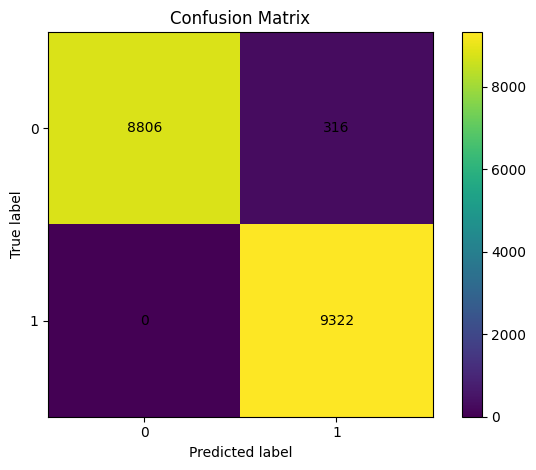

In [64]:
from sklearn.metrics import confusion_matrix

# Generate predictions first (use tuned model if available)
y_pred = svm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()
